# SAE Training on Federated Learning Checkpoints

In [1]:
# Cell 1: Environment Bootstrap
import os
REPO_URL = "https://github.com/ha405/FedMI.git"
BRANCH = "cvpr"

if not os.path.exists("FedMI"):
    get_ipython().system(f"git clone -b {BRANCH} {REPO_URL}")
else:
    # Update repo if already exists to get latest fixes
    get_ipython().system(f"cd FedMI && git pull origin {BRANCH}")

os.chdir("FedMI")

from fedmi.env import setup, CHECKPOINT_DIR, DATA_DIR
setup()

# Install dependencies required by the original notebook
%pip install -q einops opencv-python scikit-image overcomplete

remote: Enumerating objects: 6, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 4 (delta 2), reused 4 (delta 2), pack-reused 0 (from 0)
Unpacking objects: 100% (4/4), 3.41 KiB | 3.41 MiB/s, done.
From https://github.com/ha405/FedMI
 * branch            cvpr       -> FETCH_HEAD
   dccb340..b6da294  cvpr       -> origin/cvpr
Updating dccb340..b6da294
Fast-forward
 fedmi/env.py | 273 +++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
 1 file changed, 273 insertions(+)
 create mode 100644 fedmi/env.py
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.1/67.1 kB 1.4 MB/s eta 0:00:00


In [2]:
import torch
import torch.nn as nn
from typing import List
import numpy as np
import matplotlib.pyplot as plt
from einops import rearrange
from torch.utils.data import DataLoader, TensorDataset
import json
import os

import overcomplete
from overcomplete.sae import TopKSAE, JumpSAE, BatchTopKSAE, train_sae
from overcomplete.visualization import show, overlay_top_heatmaps

import sys
# sys.path.append('..') # Original path, now unnecessary as we are in the repo root

from core.config import ExperimentConfig
from core.dataset import get_dataset, get_test_dataloader

# ==========================================
# ResNet10 Architecture Definition
# ==========================================
class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()

        self.conv1 = nn.Conv2d(
            in_channels, out_channels, kernel_size=3,
            stride=stride, padding=1, bias=False
        )
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

        self.conv2 = nn.Conv2d(
            out_channels, out_channels, kernel_size=3,
            stride=1, padding=1, bias=False
        )
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.downsample = None
        if stride != 1 or in_channels != out_channels:
            self.downsample = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1,
                          stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        if self.downsample is not None:
            identity = self.downsample(identity)

        out += identity
        out = self.relu(out)

        return out


class ResNet10(nn.Module):
    def __init__(self, num_classes=1000, in_channels=3):
        super().__init__()

        self.conv1 = nn.Conv2d(
            in_channels, 64, kernel_size=7,
            stride=2, padding=3, bias=False
        )
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)

        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        # stages
        self.block1 = nn.Sequential(BasicBlock(64, 64, stride=1))
        self.block2 = nn.Sequential(BasicBlock(64, 128, stride=2))
        self.block3 = nn.Sequential(BasicBlock(128, 192, stride=2))
        self.block4 = nn.Sequential(BasicBlock(192, 256, stride=2))

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)

        return x

# ==========================================
# Utility Functions
# ==========================================

def get_model(config) -> nn.Module:
    in_channels = 1 if config.dataset_name == "MNIST" else 3
    # Use ResNet10, adapting for input channels and specific task classes
    return ResNet10(
        num_classes=5,
        in_channels=in_channels
    ).to(config.device)

def load_config_and_data(config_path):
    with open(config_path, 'r') as f:
        config_dict = json.load(f)
    # Filter out comment keys
    config_dict = {k: v for k, v in config_dict.items() if not k.startswith('_')}
    config = ExperimentConfig(**config_dict)
    # Patch paths for Cloud environment
    config.data_root = DATA_DIR
    _, testset = get_dataset(config)
    test_loader = get_test_dataloader(testset, config)
    return config, testset, test_loader

def load_model_from_checkpoint(config, path):
    model = get_model(config)
    state_dict = torch.load(path, map_location=config.device)
    model.load_state_dict(state_dict['model_state_dict'])
    model.eval()
    return model

def extract_activations(model, dataloader, config):
    model.eval()
    activations = []
    labels = []
    with torch.no_grad():
        for batch in dataloader:
            x, y = batch
            x = x.to(config.device)

            # Replicate the forward pass up to the target extraction layer (block4)
            x = model.conv1(x)
            x = model.bn1(x)
            x = model.relu(x)
            x = model.maxpool(x)

            x = model.block1(x)
            x = model.block2(x)
            x = model.block3(x)
            x = model.block4(x) # We extract from block4, the last spatial representations

            b, c, h, w = x.shape
            x_flat = rearrange(x, 'b c h w -> (b h w) c')
            activations.append(x_flat.cpu())
            y_rep = y.unsqueeze(1).repeat(1, h*w).reshape(-1)
            labels.append(y_rep.cpu())

    activations = torch.cat(activations, dim=0)
    labels = torch.cat(labels, dim=0)

    print(f"Extracted activations from block4. Shape: {activations.shape}") # Should be [N, 256] for ResNet10's block4
    return activations, labels

In [3]:
def train_jump_sae(activations, scenario_name, config):
    subset_size = min(10000, len(activations))
    activations_subset = activations[:subset_size]
    dataset = TensorDataset(activations_subset.to(config.device))
    dataloader = DataLoader(dataset, batch_size=512, shuffle=True)

    print(f"\n--- Training JumpReLU SAE for {scenario_name} ---")
    print(f"Using {subset_size} samples of size {activations.shape[-1]} for SAE training.")

    num_features = activations.shape[-1]
    sae_jump = JumpSAE(num_features, nb_concepts=num_features * 4, bandwidth=1e-2, kernel='silverman', device=config.device)
    optimizer_jump = torch.optim.Adam(sae_jump.parameters(), lr=3e-3)

    desired_sparsity = 0.10

    def criterion_jump(x, x_hat, pre_codes, codes, dictionary):
        loss = (x - x_hat).square().mean()
        sparsity = (codes > 0).float().mean().detach()
        if sparsity > desired_sparsity:
            loss -= sae_jump.thresholds.sum()
        return loss

    logs_jump = train_sae(sae_jump, dataloader, criterion_jump, optimizer_jump, nb_epochs=10, device=config.device)

    print(f"JumpReLU SAE training completed for {scenario_name}.")
    return sae_jump

## IID Experiment

In [4]:
config_iid, testset_iid, test_loader_iid = load_config_and_data('/content/config.json')

# Load IID model - Adjusting path relative to CHECKPOINT_DIR
IID_CHECKPOINT = os.path.join(CHECKPOINT_DIR, 'iid_experiment/checkpoints/checkpoint_round_5.pt')
if not os.path.exists(IID_CHECKPOINT):
    print(f"Checking fallback path for IID...")
    IID_CHECKPOINT = r"/content/iid.pt"

if os.path.exists(IID_CHECKPOINT):
    model_iid = load_model_from_checkpoint(config_iid, IID_CHECKPOINT)
    # Extract activations from 2nd layer
    activations_iid, labels_iid = extract_activations(model_iid, test_loader_iid, config_iid)
    print(f"IID Activations shape: {activations_iid.shape}")
    # Train JumpReLU SAE
    sae_iid = train_jump_sae(activations_iid, "IID", config_iid)
else:
    print(f"\u26a0\ufe0f IID checkpoint not found at {IID_CHECKPOINT}. Ensure experiments have been run.")

100%|██████████| 170M/170M [00:05<00:00, 33.7MB/s]


Checking fallback path for IID...
Extracted activations from block4. Shape: torch.Size([5000, 256])
IID Activations shape: torch.Size([5000, 256])

--- Training JumpReLU SAE for IID ---
Using 5000 samples of size 256 for SAE training.
Epoch[1/10], Loss: 3058.5886, R2: 0.3171, L0: 262.0351, Dead Features: 0.0%, Time: 0.7886 seconds
Epoch[2/10], Loss: 3027.6157, R2: 0.7297, L0: 136.9356, Dead Features: 30.5%, Time: 0.0520 seconds
Epoch[3/10], Loss: 2996.8572, R2: 0.7896, L0: 124.2308, Dead Features: 41.8%, Time: 0.0525 seconds
Epoch[4/10], Loss: 2966.1128, R2: 0.8277, L0: 126.6636, Dead Features: 45.5%, Time: 0.0510 seconds
Epoch[5/10], Loss: 2935.3748, R2: 0.8549, L0: 134.4220, Dead Features: 46.5%, Time: 0.0529 seconds
Epoch[6/10], Loss: 2904.6406, R2: 0.8768, L0: 143.6169, Dead Features: 47.2%, Time: 0.0512 seconds
Epoch[7/10], Loss: 2873.9092, R2: 0.8936, L0: 152.9882, Dead Features: 47.5%, Time: 0.0505 seconds
Epoch[8/10], Loss: 2843.1803, R2: 0.9070, L0: 160.1806, Dead Features: 47

## Non-IID Experiment

In [5]:
config_niid, testset_niid, test_loader_niid = load_config_and_data('/content/config.json')

# Load Non-IID model - Adjusting path relative to CHECKPOINT_DIR
NIID_CHECKPOINT = os.path.join(CHECKPOINT_DIR, 'niid_experiment/checkpoints/checkpoint_round_10.pt')
if not os.path.exists(NIID_CHECKPOINT):
    print(f"Checking fallback path for NIID...")
    NIID_CHECKPOINT = '/content/niid.pt'

if os.path.exists(NIID_CHECKPOINT):
    model_niid = load_model_from_checkpoint(config_niid, NIID_CHECKPOINT)
    # Extract activations from 2nd layer
    activations_niid, labels_niid = extract_activations(model_niid, test_loader_niid, config_niid)
    print(f"Non-IID Activations shape: {activations_niid.shape}")
    # Train JumpReLU SAE
    sae_niid = train_jump_sae(activations_niid, "Non-IID", config_niid)
else:
    print(f"\u26a0\ufe0f Non-IID checkpoint not found at {NIID_CHECKPOINT}.")

Checking fallback path for NIID...
Extracted activations from block4. Shape: torch.Size([5000, 256])
Non-IID Activations shape: torch.Size([5000, 256])

--- Training JumpReLU SAE for Non-IID ---
Using 5000 samples of size 256 for SAE training.
Epoch[1/10], Loss: 3058.6539, R2: 0.0978, L0: 246.5936, Dead Features: 4.2%, Time: 0.0992 seconds
Epoch[2/10], Loss: 3027.5773, R2: 0.7481, L0: 123.1482, Dead Features: 68.7%, Time: 0.0990 seconds
Epoch[3/10], Loss: 2996.8092, R2: 0.8196, L0: 112.9448, Dead Features: 74.8%, Time: 0.1720 seconds
Epoch[4/10], Loss: 2966.0619, R2: 0.8543, L0: 111.7904, Dead Features: 76.3%, Time: 0.1466 seconds
Epoch[5/10], Loss: 2935.3234, R2: 0.8751, L0: 113.1711, Dead Features: 76.9%, Time: 0.1174 seconds
Epoch[6/10], Loss: 2904.5897, R2: 0.8895, L0: 115.4059, Dead Features: 76.9%, Time: 0.4961 seconds
Epoch[7/10], Loss: 2873.8587, R2: 0.9003, L0: 117.3127, Dead Features: 77.3%, Time: 0.1318 seconds
Epoch[8/10], Loss: 2843.1295, R2: 0.9090, L0: 119.4699, Dead Fea

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

print("\n==============================")
print("SAE GEOMETRY ANALYSIS START")
print("==============================\n")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

sae_iid = sae_iid.to(device)
sae_niid = sae_niid.to(device)

# Ensure data is on CPU for sklearn/numpy but keep tensors for torch operations
acts_iid_t = torch.as_tensor(activations_iid).float()
acts_niid_t = torch.as_tensor(activations_niid).float()
labs_iid_np = np.array(labels_iid)
labs_niid_np = np.array(labels_niid)

print("IID activation shape:", acts_iid_t.shape)
print("Non-IID activation shape:", acts_niid_t.shape)

# --------------------------------------------------
# 1. Extract dictionary feature vectors
# --------------------------------------------------
print("\n[1] Extracting dictionary feature directions")

# Dict shape: [nb_concepts, d_model]
D_iid = sae_iid.dictionary._weights.detach().cpu()
D_niid = sae_niid.dictionary._weights.detach().cpu()

# Normalize directions to unit sphere for cosine similarity
D_iid_norm = torch.nn.functional.normalize(D_iid, dim=1)
D_niid_norm = torch.nn.functional.normalize(D_niid, dim=1)

print("IID dictionary:", D_iid.shape)
print("Non-IID dictionary:", D_niid.shape)

# --------------------------------------------------
# 2. Cross-model feature similarity
# --------------------------------------------------
print("\n[2] Cross-model feature similarity")

sim_matrix = torch.matmul(D_iid_norm, D_niid_norm.T)
max_sim = sim_matrix.max(dim=1).values

print("Mean max similarity:", max_sim.mean().item())
print("Median max similarity:", max_sim.median().item())

plt.figure(figsize=(6,4))
plt.hist(max_sim.numpy(), bins=50, color='skyblue', edgecolor='black')
plt.title("Max Cosine Similarity (Matched IID vs Non-IID Features)")
plt.xlabel("Cosine Similarity")
plt.show()

# --------------------------------------------------
# 3. Internal feature geometry
# --------------------------------------------------
print("\n[3] Internal feature geometry")

sim_iid = torch.matmul(D_iid_norm, D_iid_norm.T)
sim_niid = torch.matmul(D_niid_norm, D_niid_norm.T)

# Mask diagonal to compare features to others
mask = ~torch.eye(sim_iid.shape[0], dtype=bool)
iid_vals = sim_iid[mask].numpy()
niid_vals = sim_niid[mask].numpy()

print("IID mean pairwise similarity:", iid_vals.mean())
print("Non-IID mean pairwise similarity:", niid_vals.mean())

plt.figure(figsize=(6,4))
plt.hist(iid_vals, bins=60, alpha=0.5, label="IID", density=True)
plt.hist(niid_vals, bins=60, alpha=0.5, label="Non-IID", density=True)
plt.legend()
plt.title("Internal Feature Coherence (Pairwise Similarity)")
plt.show()

# --------------------------------------------------
# 4. PCA visualization
# --------------------------------------------------
print("\n[4] PCA geometry")

pca = PCA(n_components=2)
p_iid = pca.fit_transform(D_iid.numpy())
p_niid = pca.fit_transform(D_niid.numpy())

fig, ax = plt.subplots(1, 2, figsize=(12,5))
ax[0].scatter(p_iid[:,0], p_iid[:,1], alpha=0.6, c='blue')
ax[0].set_title("IID Feature Space (PCA)")
ax[1].scatter(p_niid[:,0], p_niid[:,1], alpha=0.6, c='red')
ax[1].set_title("Non-IID Feature Space (PCA)")
plt.show()

# --------------------------------------------------
# 5. Encode activations through SAE
# --------------------------------------------------
print("\n[5] Computing SAE feature activations")

def encode_features(sae, activations):
    x = activations.to(device)
    with torch.no_grad():
        z = sae.encode(x)
    if isinstance(z, tuple): z = z[0]
    return z.detach().cpu()

f_iid = encode_features(sae_iid, acts_iid_t)
f_niid = encode_features(sae_niid, acts_niid_t)

print("IID active feature fraction:", (f_iid > 0).float().mean().item())
print("Non-IID active feature fraction:", (f_niid > 0).float().mean().item())

# --------------------------------------------------
# 6. Feature utilization entropy
# --------------------------------------------------
print("\n[6] Feature entropy")

def feature_entropy(features):
    # Calculate how often each feature is used (probability distribution over features)
    usage = (features > 0).float().sum(0)
    p = usage / (usage.sum() + 1e-8)
    # Shannon Entropy: -sum(p * log p)
    entropy = -(p * torch.log(p + 1e-8)).sum()
    # Normalized Entropy (0 to 1)
    max_entropy = np.log(features.shape[1])
    return entropy / max_entropy

ent_iid = feature_entropy(f_iid)
ent_niid = feature_entropy(f_niid)

print(f"IID Normalized Feature Entropy: {ent_iid.item():.4f}")
print(f"Non-IID Normalized Feature Entropy: {ent_niid.item():.4f}")
print("(High entropy = model uses features uniformly; Low = model relies on very few features)")

# --------------------------------------------------
# 7. Buried knowledge test (Per-Class Projection)
# --------------------------------------------------
print("\n[7] Per-Class Projection: Non-IID activations onto IID features")

# Project Non-IID raw activations onto the IID dictionary directions
# This tells us: "Do the Non-IID activations contain the concepts learned by the IID model?"
proj_niid_on_iid = acts_niid_t @ D_iid_norm.T

classes = np.unique(labs_niid_np)
per_class_stats = {}

for cls in classes:
    mask = (labs_niid_np == cls)
    if not np.any(mask): continue

    cls_projections = proj_niid_on_iid[mask]
    avg_proj = cls_projections.mean().item()
    max_feat_val, max_feat_idx = cls_projections.mean(0).max(0)

    per_class_stats[cls] = {'avg': avg_proj, 'top_feat': max_feat_idx.item(), 'top_val': max_feat_val.item()}
    print(f"Class {int(cls)} | Mean Projection: {avg_proj:.4f} | Strongest IID Feature: {max_feat_idx.item()} (val: {max_feat_val.item():.4f})")

# --------------------------------------------------
# 8. Similarity heatmaps
# --------------------------------------------------
print("\n[8] Feature similarity heatmaps")

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(sim_iid.numpy()[:100, :100], cmap="RdBu_r", center=0, ax=ax[0])
ax[0].set_title("IID Feature Similarity (Subset 100x100)")
sns.heatmap(sim_niid.numpy()[:100, :100], cmap="RdBu_r", center=0, ax=ax[1])
ax[1].set_title("Non-IID Feature Similarity (Subset 100x100)")
plt.show()

print("\n==============================")
print("ANALYSIS COMPLETE")
print("==============================")

In [ ]:
from fedmi.env import show_images
show_images()

## Download Results

In [ ]:
import shutil
from IPython.display import FileLink

if os.path.isdir(CHECKPOINT_DIR):
    output_zip = "sae_experiment_results.zip"
    shutil.make_archive(output_zip.replace('.zip', ''), 'zip', CHECKPOINT_DIR)
    print(f"Results zipped to {output_zip}")
    display(FileLink(output_zip))
else:
    print("⚠ No results found in checkpoint directory.")

USAE


UNIVERSAL SAE (USAE) TRAINING (FOR RESNET10 BLOCK4)

Training Universal SAE on block4 features (Dim=256).
Shared Concepts: 2048 | TopK: 32 | Epochs: 300
Epoch 001/300 - Total Universal Loss (MSE): 1.7450
Epoch 005/300 - Total Universal Loss (MSE): 0.6025
Epoch 010/300 - Total Universal Loss (MSE): 0.3589
Epoch 015/300 - Total Universal Loss (MSE): 0.2629
Epoch 020/300 - Total Universal Loss (MSE): 0.2079
Epoch 025/300 - Total Universal Loss (MSE): 0.1884
Epoch 030/300 - Total Universal Loss (MSE): 0.1906
Epoch 035/300 - Total Universal Loss (MSE): 0.2051
Epoch 040/300 - Total Universal Loss (MSE): 0.1676
Epoch 045/300 - Total Universal Loss (MSE): 0.1724
Epoch 050/300 - Total Universal Loss (MSE): 0.1663
Epoch 055/300 - Total Universal Loss (MSE): 0.1471
Epoch 060/300 - Total Universal Loss (MSE): 0.1641
Epoch 065/300 - Total Universal Loss (MSE): 0.1171
Epoch 070/300 - Total Universal Loss (MSE): 0.1449
Epoch 075/300 - Total Universal Loss (MSE): 0.1423
Epoch 080/300 - Total Universa

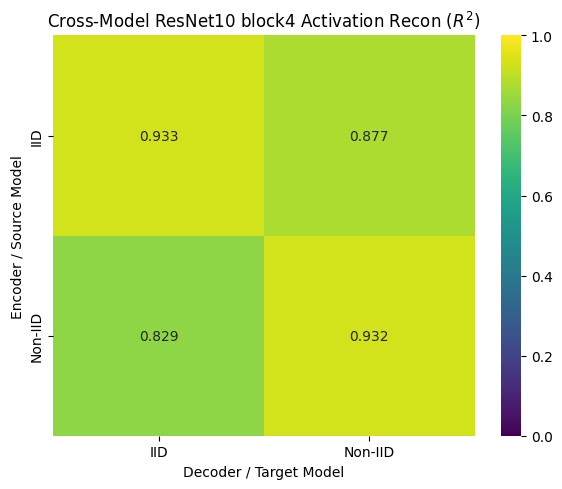

In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import random
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("\n===========================================")
print("UNIVERSAL SAE (USAE) TRAINING (FOR RESNET10 BLOCK4)")
print("===========================================\n")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class UniversalSAE(nn.Module):
    """
    Universal Sparse Autoencoder (USAE)
    Learns a shared concept space Z across M different models.
    """
    def __init__(self, num_models, input_dim, num_concepts, top_k=32):
        super().__init__()
        self.num_models = num_models
        self.input_dim = input_dim
        self.num_concepts = num_concepts
        self.top_k = top_k

        # M Encoders
        self.W_enc = nn.ParameterList([
            nn.Parameter(torch.randn(input_dim, num_concepts) / (input_dim**0.5))
            for _ in range(num_models)
        ])
        self.b_pre = nn.ParameterList([
            nn.Parameter(torch.zeros(input_dim))
            for _ in range(num_models)
        ])

        # Batch Norm per model (following Appendix A.1)
        self.bn = nn.ModuleList([
            nn.BatchNorm1d(num_concepts)
            for _ in range(num_models)
        ])

        # M Decoders
        self.D = nn.ParameterList([
            nn.Parameter(torch.randn(num_concepts, input_dim) / (num_concepts**0.5))
            for _ in range(num_models)
        ])

    def encode(self, x, model_idx):
        # Apply pre-bias and encode
        h = (x - self.b_pre[model_idx]) @ self.W_enc[model_idx]
        # BatchNorm and ReLU
        h = F.relu(self.bn[model_idx](h))

        # TopK Sparsity Enforcement
        top_vals, top_idx = torch.topk(h, self.top_k, dim=-1)
        z = torch.zeros_like(h)
        z.scatter_(-1, top_idx, top_vals)
        return z

    def decode(self, z, model_idx):
        return z @ self.D[model_idx]


min_size = min(len(activations_iid), len(activations_niid))

# Subsample: Increased to 40k since ResNet10 spatial dimensions are smaller, saving VRAM
subset_size = min(40000, min_size)
A_iid_t = activations_iid[:subset_size].to(device)
A_niid_t = activations_niid[:subset_size].to(device)

dataset = TensorDataset(A_iid_t, A_niid_t)
# Increased batch size for smoother SAE gradients
dataloader = DataLoader(dataset, batch_size=1024, shuffle=True)

input_dim = A_iid_t.shape[-1] # Expected to be 256 for ResNet10 block4
expansion_factor = 8          # 8x overcomplete (Yields 2048 concepts)
num_concepts = input_dim * expansion_factor
top_k = 32                    # Hardcoded Top-K (Standard for SAEs of this size)

usae = UniversalSAE(
    num_models=2,
    input_dim=input_dim,
    num_concepts=num_concepts,
    top_k=top_k
).to(device)

# Using a single global optimizer ensures that ALL decoders update
optimizer = torch.optim.Adam(usae.parameters(), lr=1e-3)

num_epochs = 300
print(f"Training Universal SAE on block4 features (Dim={input_dim}).")
print(f"Shared Concepts: {num_concepts} | TopK: {top_k} | Epochs: {num_epochs}")

usae.train()
for epoch in range(num_epochs):
    total_loss = 0.0
    for batch in dataloader:
        A_batch = batch
        i = random.randint(0, usae.num_models - 1)

        optimizer.zero_grad()
        Z = usae.encode(A_batch[i], i)

        loss = 0.0
        for j in range(usae.num_models):
            A_hat_j = usae.decode(Z, j)
            # F.mse_loss is much more numerically stable for backprop than torch.norm (Frobenius)
            loss += F.mse_loss(A_hat_j, A_batch[j])

        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:03d}/{num_epochs} - Total Universal Loss (MSE): {total_loss/len(dataloader):.4f}")

print("USAE training completed.")
print("\n[Evaluating Cross-Model Activation Reconstruction (R^2 Score)]")

def calculate_r2(true_A, recon_A):
    ss_res = ((true_A - recon_A)**2).sum()
    ss_tot = ((true_A - true_A.mean(dim=0))**2).sum()
    return max(0.0, (1 - ss_res / ss_tot).item())

usae.eval()
with torch.no_grad():
    labels = ["IID", "Non-IID"]
    A_eval = [A_iid_t, A_niid_t]

    # Store R^2 matrix [Encoder_i, Decoder_j]
    r2_matrix = np.zeros((2, 2))

    for i in range(2):
        Z = usae.encode(A_eval[i], i)
        for j in range(2):
            A_hat = usae.decode(Z, j)
            r2_matrix[i, j] = calculate_r2(A_eval[j], A_hat)

    print(f"{'Encoder':<15} | {'Decoder':<15} | R^2 Score")
    print("-" * 45)
    for i in range(2):
        for j in range(2):
            recons_type = "Self-Recon" if i == j else "Cross-Recon"
            print(f"{labels[i]:<15} | {labels[j]:<15} | {r2_matrix[i,j]:.4f} ({recons_type})")

print("\n[Checking Sparsity Level]")

with torch.no_grad():
    Z_iid = usae.encode(A_iid_t, 0)
    Z_niid = usae.encode(A_niid_t, 1)

    iid_active = (Z_iid > 0).float().sum(dim=1).mean().item()
    niid_active = (Z_niid > 0).float().sum(dim=1).mean().item()

print(f"Expected active concepts (TopK): {top_k}")
print(f"IID avg active concepts: {iid_active:.2f}")
print(f"Non-IID avg active concepts: {niid_active:.2f}")

# Visualizing the R2 Matrix
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(r2_matrix, annot=True, fmt=".3f", cmap="viridis",
            xticklabels=labels, yticklabels=labels, ax=ax, vmin=0, vmax=1)
ax.set_title("Cross-Model ResNet10 block4 Activation Recon ($R^2$)")
ax.set_xlabel("Decoder / Target Model")
ax.set_ylabel("Encoder / Source Model")
plt.tight_layout()
plt.show()

Total Active Concepts: 2002 / 2048
Concepts Unique to IID Model: 717
Concepts Unique to Non-IID Model: 662


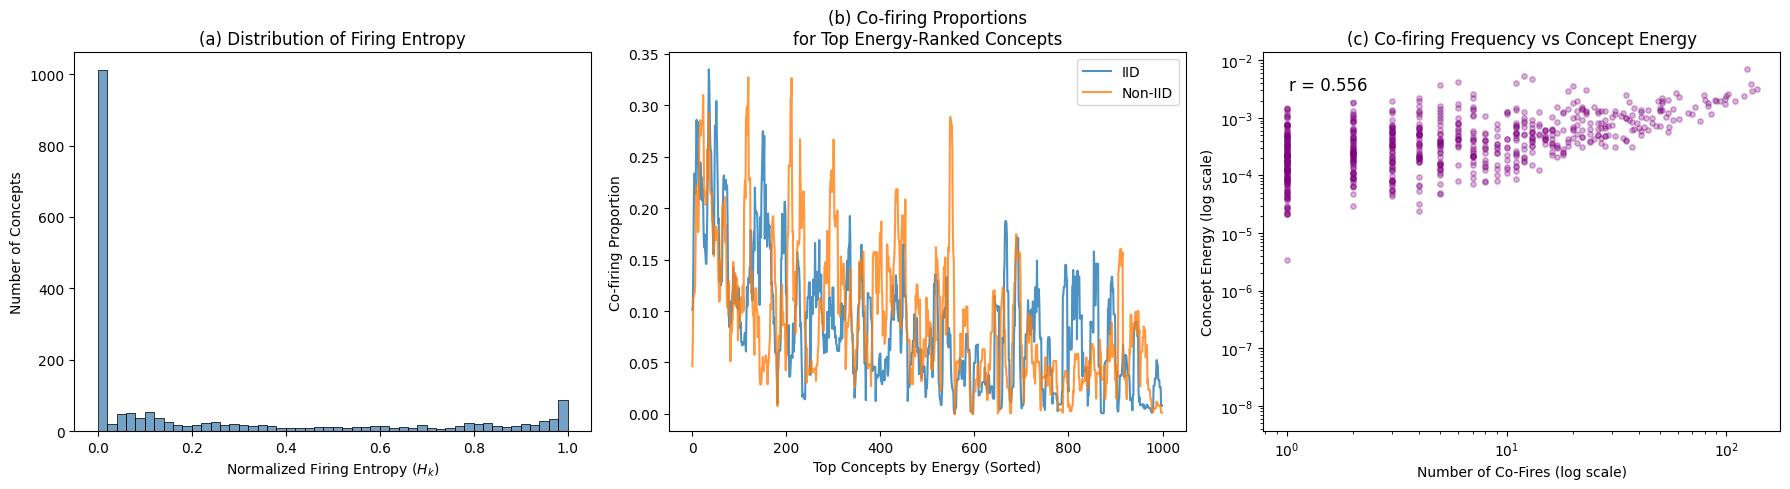

In [7]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

usae.eval()
with torch.no_grad():
    Z_iid = usae.encode(A_iid_t, 0)
    Z_niid = usae.encode(A_niid_t, 1)
    fires_iid = (Z_iid > 0).float()
    fires_niid = (Z_niid > 0).float()
    co_fires = fires_iid * fires_niid

    total_iid = fires_iid.sum(dim=0)
    total_niid = fires_niid.sum(dim=0)
    total_co_fires = co_fires.sum(dim=0)
    total_any_fires = total_iid + total_niid
    active_mask = total_any_fires > 0
    p_iid = total_iid / (total_any_fires + 1e-9)
    p_niid = total_niid / (total_any_fires + 1e-9)
    p_iid_active = p_iid[active_mask]
    p_niid_active = p_niid[active_mask]
    entropy_active = -(p_iid_active * torch.log2(p_iid_active + 1e-9) +
                       p_niid_active * torch.log2(p_niid_active + 1e-9))

    def get_concept_energies(Z, decoder_weights):
        expected_Z = Z.mean(dim=0)
        contributions = expected_Z.unsqueeze(1) * decoder_weights
        return torch.norm(contributions, p=2, dim=1)**2

    energy_iid = get_concept_energies(Z_iid, usae.D[0])
    energy_niid = get_concept_energies(Z_niid, usae.D[1])
    avg_energy = (energy_iid + energy_niid) / 2.0

    cfp_iid = total_co_fires / (total_iid + 1e-9)
    cfp_niid = total_co_fires / (total_niid + 1e-9)

    sorted_indices = torch.argsort(avg_energy, descending=True)
    top_k_plot = min(1000, len(sorted_indices))

    sorted_cfp_iid = cfp_iid[sorted_indices][:top_k_plot].cpu().numpy()
    sorted_cfp_niid = cfp_niid[sorted_indices][:top_k_plot].cpu().numpy()

    unique_to_iid = torch.where((total_iid > 10) & (p_iid > 0.95))[0]
    unique_to_niid = torch.where((total_niid > 10) & (p_niid > 0.95))[0]

    print(f"Total Active Concepts: {active_mask.sum().item()} / {Z_iid.shape[1]}")
    print(f"Concepts Unique to IID Model: {len(unique_to_iid)}")
    print(f"Concepts Unique to Non-IID Model: {len(unique_to_niid)}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(entropy_active.cpu().numpy(), bins=50, ax=axes[0], color='steelblue')
axes[0].set_title("(a) Distribution of Firing Entropy")
axes[0].set_xlabel("Normalized Firing Entropy ($H_k$)")
axes[0].set_ylabel("Number of Concepts")
axes[0].set_xlim(-0.05, 1.05)
def smooth(y, box_pts):
    box = np.ones(box_pts)/box_pts
    return np.convolve(y, box, mode='same')

axes[1].plot(smooth(sorted_cfp_iid, 10), label='IID', alpha=0.8)
axes[1].plot(smooth(sorted_cfp_niid, 10), label='Non-IID', alpha=0.8)
axes[1].set_title("(b) Co-firing Proportions\nfor Top Energy-Ranked Concepts")
axes[1].set_xlabel("Top Concepts by Energy (Sorted)")
axes[1].set_ylabel("Co-firing Proportion")
axes[1].legend()

x_data = total_co_fires[active_mask].cpu().numpy()
y_data = avg_energy[active_mask].cpu().numpy()

axes[2].scatter(x_data, y_data, alpha=0.3, s=15, color='purple')
axes[2].set_title("(c) Co-firing Frequency vs Concept Energy")
axes[2].set_xlabel("Number of Co-Fires (log scale)")
axes[2].set_ylabel("Concept Energy (log scale)")
axes[2].set_xscale('log')
axes[2].set_yscale('log')

valid = (x_data > 0) & (y_data > 0)
if valid.sum() > 1:
    r = np.corrcoef(np.log10(x_data[valid]), np.log10(y_data[valid]))[0, 1]
    axes[2].text(0.05, 0.9, f"r = {r:.3f}", transform=axes[2].transAxes, fontsize=12,
                 bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

plt.tight_layout()
plt.show()

In [8]:
import torch
from tqdm import tqdm
from einops import rearrange
import numpy as np

# Ensure device is defined
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def get_accuracy(model, dataloader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for x, y in dataloader:
            x, y = x.to(device), y.to(device)
            outputs = model(x)
            _, predicted = torch.max(outputs.data, 1)
            total += y.size(0)
            correct += (predicted == y).sum().item()
    return correct / total

def evaluate_usae_performance(source_idx, target_idx, source_model, target_model, usae, dataloader, mask=None):
    source_model.eval()
    target_model.eval()
    usae.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in dataloader:
            x, y = x.to(device), y.to(device)

            # 1. Source feature extraction (ResNet10 up to block4)
            feat = source_model.conv1(x)
            feat = source_model.bn1(feat)
            feat = source_model.relu(feat)
            feat = source_model.maxpool(feat)

            feat = source_model.block1(feat)
            feat = source_model.block2(feat)
            feat = source_model.block3(feat)
            feat = source_model.block4(feat)

            # Flatten spatial dimensions for USAE
            b, c, h, w = feat.shape
            feat_flat = rearrange(feat, 'b c h w -> (b h w) c')

            # 2. Encode into shared concept space
            Z = usae.encode(feat_flat, source_idx)

            # Apply masking (isolate shared vs unique concepts)
            if mask is not None:
                Z = Z * mask

            # 3. Decode into target model's activation space
            recon_flat = usae.decode(Z, target_idx)

            # Reshape back to spatial dimensions
            recon_feat = rearrange(recon_flat, '(b h w) c -> b c h w', b=b, h=h, w=w).contiguous()

            # 4. Target forward pass completion (ResNet10 after block4)
            out = target_model.avgpool(recon_feat)
            out = torch.flatten(out, 1)
            logits = target_model.fc(out)

            # Calculate accuracy
            _, predicted = torch.max(logits.data, 1)
            total += y.size(0)
            correct += (predicted == y).sum().item()

    return correct / total

# ==========================================
# Run Evaluation
# ==========================================

usae.eval()
with torch.no_grad():
    Z_iid = usae.encode(A_iid_t, 0)
    Z_niid = usae.encode(A_niid_t, 1)

    # Identify which concepts ever fire (>0) for each distribution
    active_iid = (Z_iid > 0).any(dim=0)
    active_niid = (Z_niid > 0).any(dim=0)

    # Create binary masks for different concept families
    mask_shared = (active_iid & active_niid).float()
    mask_iid_only = (active_iid & ~active_niid).float()
    mask_niid_only = (~active_iid & active_niid).float()

families = [
    ("Shared Concepts", mask_shared),
    ("IID-Unique Concepts", mask_iid_only),
    ("Non-IID-Unique Concepts", mask_niid_only)
]

print("Calculating Baselines...")
acc_iid_base = get_accuracy(model_iid, test_loader_iid)
acc_niid_base = get_accuracy(model_niid, test_loader_niid)

print("\n" + "="*85)
print(f"{'Concept Family':<25} | {'Source':<8} -> {'Target':<8} | Accuracy | % of Base")
print("-" * 85)

for name, mask in families:
    active_count = int(mask.sum().item())

    # Self-Reconstruction Performance
    acc_ii = evaluate_usae_performance(0, 0, model_iid, model_iid, usae, test_loader_iid, mask)
    acc_nn = evaluate_usae_performance(1, 1, model_niid, model_niid, usae, test_loader_niid, mask)

    # Cross-Model Stitching Performance
    acc_in = evaluate_usae_performance(0, 1, model_iid, model_niid, usae, test_loader_iid, mask)
    acc_ni = evaluate_usae_performance(1, 0, model_niid, model_iid, usae, test_loader_niid, mask)

    print(f"{name:<25} ({active_count:4d} concepts)")
    print(f"{'':<25} | {'IID':<8} -> {'IID':<8} | {acc_ii:.4f}   | {(acc_ii/acc_iid_base)*100:6.1f}%")
    print(f"{'':<25} | {'NIID':<8} -> {'NIID':<8} | {acc_nn:.4f}   | {(acc_nn/acc_niid_base)*100:6.1f}%")
    print(f"{'':<25} | {'IID':<8} -> {'NIID':<8} | {acc_in:.4f}   | {(acc_in/acc_niid_base)*100:6.1f}%") # Evaluated against target base
    print(f"{'':<25} | {'NIID':<8} -> {'IID':<8} | {acc_ni:.4f}   | {(acc_ni/acc_iid_base)*100:6.1f}%")  # Evaluated against target base
    print("-" * 85)

print(f"{'Full USAE (All Concepts)':<25}")
acc_full_in = evaluate_usae_performance(0, 1, model_iid, model_niid, usae, test_loader_iid)
acc_full_ni = evaluate_usae_performance(1, 0, model_niid, model_iid, usae, test_loader_niid)
print(f"{'':<25} | {'IID':<8} -> {'NIID':<8} | {acc_full_in:.4f}   | {(acc_full_in/acc_niid_base)*100:6.1f}%")
print(f"{'':<25} | {'NIID':<8} -> {'IID':<8} | {acc_full_ni:.4f}   | {(acc_full_ni/acc_iid_base)*100:6.1f}%")
print("="*85)

Calculating Baselines...

Concept Family            | Source   -> Target   | Accuracy | % of Base
-------------------------------------------------------------------------------------
Shared Concepts           ( 991 concepts)
                          | IID      -> IID      | 0.6940   |   98.3%
                          | NIID     -> NIID     | 0.3574   |   97.2%
                          | IID      -> NIID     | 0.3550   |   96.6%
                          | NIID     -> IID      | 0.6678   |   94.6%
-------------------------------------------------------------------------------------
IID-Unique Concepts       ( 534 concepts)
                          | IID      -> IID      | 0.5924   |   83.9%
                          | NIID     -> NIID     | 0.2000   |   54.4%
                          | IID      -> NIID     | 0.2828   |   76.9%
                          | NIID     -> IID      | 0.2000   |   28.3%
-------------------------------------------------------------------------------------


In [24]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torchvision
import torchvision.transforms as transforms
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


class LinearProbe(nn.Module):
    def __init__(self, input_dim=256, num_classes=5):
        super().__init__()
        self.fc = nn.Linear(input_dim, num_classes)

    def forward(self, x):
        return self.fc(x)


def get_resnet_features(model, x):
    with torch.no_grad():
        x = model.conv1(x)
        x = model.bn1(x)
        x = model.relu(x)
        x = model.maxpool(x)
        x = model.block1(x)
        x = model.block2(x)
        x = model.block3(x)
        x = model.block4(x)
        x = model.avgpool(x)
        x = torch.flatten(x, 1)
    return x


def filter_dataset(dataset):
    data = []
    labels = []

    for img, label in dataset:
        if label < 5:
            data.append(img)
            labels.append(label)

    data = torch.stack(data)
    labels = torch.tensor(labels)

    return TensorDataset(data, labels)


def extract_features(backbone, loader):
    backbone.eval()

    all_features = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            features = get_resnet_features(backbone, images)

            all_features.append(features.cpu())
            all_labels.append(labels)

    features = torch.cat(all_features)
    labels = torch.cat(all_labels)

    return TensorDataset(features, labels)


def train_probe(feature_loader, epochs=100):

    probe = LinearProbe(input_dim=256, num_classes=5).to(device)

    optimizer = optim.Adam(probe.parameters(), lr=1e-4)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs):

        probe.train()

        total_loss = 0
        correct = 0
        total = 0

        for features, labels in feature_loader:

            features = features.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            logits = probe(features)
            loss = criterion(logits, labels)

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

            _, predicted = torch.max(logits, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        print(
            f"Epoch {epoch+1:02d}: "
            f"Loss = {total_loss/len(feature_loader):.4f} | "
            f"Acc = {correct/total:.4f}"
        )

    return probe


def evaluate_probe(probe, feature_loader):

    probe.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for features, labels in feature_loader:

            features = features.to(device)
            labels = labels.to(device)

            logits = probe(features)

            _, predicted = torch.max(logits, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return correct / total


transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])


raw_train = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

raw_test = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)


train_dataset = filter_dataset(raw_train)
test_dataset = filter_dataset(raw_test)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)


print("Extracting IID backbone features...")
iid_train_features = extract_features(model_iid, train_loader)
iid_test_features = extract_features(model_iid, test_loader)

print("Extracting NIID backbone features...")
niid_train_features = extract_features(model_niid, train_loader)
niid_test_features = extract_features(model_niid, test_loader)


iid_train_loader = DataLoader(iid_train_features, batch_size=128, shuffle=True)
iid_test_loader = DataLoader(iid_test_features, batch_size=128, shuffle=False)

niid_train_loader = DataLoader(niid_train_features, batch_size=128, shuffle=True)
niid_test_loader = DataLoader(niid_test_features, batch_size=128, shuffle=False)


print("\n--- Training IID Probe ---")
probe_iid = train_probe(iid_train_loader)

print("\n--- Training NIID Probe ---")
probe_niid = train_probe(niid_train_loader)


print("\n" + "="*70)

acc_iid = evaluate_probe(probe_iid, iid_test_loader)
print(f"IID Probe on IID Features  : {acc_iid:.4f}")

acc_niid = evaluate_probe(probe_niid, niid_test_loader)
print(f"NIID Probe on NIID Features: {acc_niid:.4f}")

print("="*70)

Extracting IID backbone features...
Extracting NIID backbone features...

--- Training IID Probe ---
Epoch 01: Loss = 1.2923 | Acc = 0.5167
Epoch 02: Loss = 0.9824 | Acc = 0.6654
Epoch 03: Loss = 0.8732 | Acc = 0.6985
Epoch 04: Loss = 0.8191 | Acc = 0.7077
Epoch 05: Loss = 0.7857 | Acc = 0.7153
Epoch 06: Loss = 0.7645 | Acc = 0.7193
Epoch 07: Loss = 0.7479 | Acc = 0.7221
Epoch 08: Loss = 0.7355 | Acc = 0.7249
Epoch 09: Loss = 0.7262 | Acc = 0.7267
Epoch 10: Loss = 0.7187 | Acc = 0.7291
Epoch 11: Loss = 0.7131 | Acc = 0.7293
Epoch 12: Loss = 0.7058 | Acc = 0.7313
Epoch 13: Loss = 0.7023 | Acc = 0.7321
Epoch 14: Loss = 0.6975 | Acc = 0.7334
Epoch 15: Loss = 0.6933 | Acc = 0.7348
Epoch 16: Loss = 0.6906 | Acc = 0.7352
Epoch 17: Loss = 0.6872 | Acc = 0.7358
Epoch 18: Loss = 0.6849 | Acc = 0.7365
Epoch 19: Loss = 0.6816 | Acc = 0.7370
Epoch 20: Loss = 0.6796 | Acc = 0.7379
Epoch 21: Loss = 0.6766 | Acc = 0.7388
Epoch 22: Loss = 0.6759 | Acc = 0.7389
Epoch 23: Loss = 0.6733 | Acc = 0.7394
Ep